# LangGraph Multi-Agent Research and Summarization System

**LLM Backend:** Groq (llama-3.3-70b-versatile)  
**Embeddings:** HuggingFace (all-MiniLM-L6-v2, free / local)  
**Web Search:** Tavily  
**Vector Store:** ChromaDB

## Architecture
```
__start__ → router → [llm | rag | web_research] → summarization → __end__
```

## 1. Install Dependencies

In [1]:
!pip install -q langgraph langchain langchain-groq langchain-community \
    langchain-chroma chromadb sentence-transformers tavily-python \
    langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/6

## 2. Imports and Configuration

In [2]:
import os, json, operator
from typing import TypedDict, Annotated, Literal, List
from datetime import datetime

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document

# ── API Keys ──────────────────────────────────────────────────────────────
import os
from google.colab import userdata

os.environ['GROQ_API_KEY']   = userdata.get('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

print('API keys loaded from Colab secrets.')

print('Imports complete.')

API keys loaded from Colab secrets.
Imports complete.


## 3. Graph State Definition

In [3]:
class AgentState(TypedDict):
    """Shared state flowing through every LangGraph node."""
    query:             str
    route:             str          # 'llm' | 'rag' | 'web_research'
    retrieved_context: str
    llm_response:      str
    final_summary:     str
    messages:          Annotated[List[BaseMessage], operator.add]
    metadata:          dict

print('AgentState defined.')

AgentState defined.


## 4. LLM and Tool Initialization

In [4]:
# ── Groq LLM (ultra-fast inference) ─────────────────────────────────────
llm = ChatGroq(
    model='llama-3.3-70b-versatile',  # top open model on Groq
    temperature=0,
    max_tokens=2048,
)

# ── Web Search (Tavily) ──────────────────────────────────────────────────
web_search_tool = TavilySearchResults(
    max_results=5,
    search_depth='advanced',
    include_answer=True,
    include_raw_content=False,
)

# ── Local HuggingFace Embeddings (no API key needed) ────────────────────
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True},
)

print('Groq LLM, Tavily search, and HuggingFace embeddings initialized.')

/tmp/ipython-input-1451335531.py:9: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Groq LLM, Tavily search, and HuggingFace embeddings initialized.


## 5. RAG Knowledge Base Setup

Sample AI/ML documents are used as the knowledge base.  
Replace or extend `sample_documents` with any domain corpus you have.

In [5]:
sample_documents = [
    Document(
        page_content=(
            'LangGraph is a framework built on top of LangChain for creating stateful, '
            'multi-actor applications with LLMs. It coordinates multiple chains or agents '
            'across computation steps in a cyclic manner, enabling robust production-ready '
            'agent architectures with conditional routing and shared state.'
        ),
        metadata={'source': 'langgraph_docs', 'topic': 'langgraph'},
    ),
    Document(
        page_content=(
            'Retrieval-Augmented Generation (RAG) enhances LLMs by retrieving relevant '
            'documents from an external knowledge base before generating a response. '
            'RAG reduces hallucinations and provides factual, grounded answers by combining '
            'retrieval-based and generative AI methods.'
        ),
        metadata={'source': 'ml_textbook', 'topic': 'rag'},
    ),
    Document(
        page_content=(
            'Vector databases store data as high-dimensional vectors and support fast '
            'similarity search using approximate nearest neighbor (ANN) algorithms. '
            'Popular options include Pinecone, Weaviate, Milvus, Qdrant, and Chroma. '
            'They are widely used in semantic search and RAG pipelines.'
        ),
        metadata={'source': 'db_guide', 'topic': 'vector_databases'},
    ),
    Document(
        page_content=(
            "Transformer architecture, introduced in 'Attention is All You Need' "
            '(Vaswani et al., 2017), revolutionized NLP using self-attention mechanisms. '
            'Modern LLMs such as GPT-4, Llama 3, Mistral, Claude, and Gemini are all '
            'based on the Transformer architecture.'
        ),
        metadata={'source': 'dl_survey', 'topic': 'transformers'},
    ),
    Document(
        page_content=(
            'Prompt engineering designs effective input prompts to guide LLMs toward desired '
            'outputs. Key techniques: zero-shot prompting, few-shot prompting, '
            'chain-of-thought (CoT) prompting, and role-based prompting. These significantly '
            'improve accuracy without fine-tuning.'
        ),
        metadata={'source': 'prompt_guide', 'topic': 'prompt_engineering'},
    ),
    Document(
        page_content=(
            'Fine-tuning further trains a pre-trained model on domain-specific data. '
            'Popular LLM fine-tuning methods include full fine-tuning, LoRA '
            '(Low-Rank Adaptation), QLoRA, and instruction tuning. Fine-tuning helps '
            'models specialize while retaining general knowledge.'
        ),
        metadata={'source': 'ml_textbook', 'topic': 'fine_tuning'},
    ),
    Document(
        page_content=(
            'Multi-agent systems consist of multiple autonomous agents that collaborate '
            'to solve complex problems. In LLM-based systems agents are specialized for '
            'research, coding, planning, or summarization. Frameworks like LangGraph, '
            'AutoGen, and CrewAI enable sophisticated multi-agent pipelines.'
        ),
        metadata={'source': 'agent_survey', 'topic': 'multi_agent'},
    ),
    Document(
        page_content=(
            'RLHF (Reinforcement Learning from Human Feedback) aligns LLMs with human '
            'preferences through supervised fine-tuning (SFT), reward model training, '
            'and PPO policy optimization. It was used to train InstructGPT and ChatGPT.'
        ),
        metadata={'source': 'alignment_paper', 'topic': 'rlhf'},
    ),
    Document(
        page_content=(
            'Groq is an AI infrastructure company that provides ultra-fast LLM inference '
            'using custom LPU (Language Processing Unit) hardware. Groq supports open '
            'models such as Llama 3, Mixtral, and Gemma and offers a free API tier '
            'at console.groq.com, making it ideal for rapid prototyping.'
        ),
        metadata={'source': 'groq_docs', 'topic': 'groq'},
    ),
]

vectorstore = Chroma.from_documents(
    documents=sample_documents,
    embedding=embeddings,
    collection_name='ai_knowledge_base',
    persist_directory='./chroma_db',
)
retriever = vectorstore.as_retriever(search_kwargs={'k': 3})
print(f'Knowledge base ready with {len(sample_documents)} documents.')

Knowledge base ready with 9 documents.


## 6. Agent Node Implementations

### 6.1 Router Agent

In [6]:
ROUTER_SYSTEM_PROMPT = """\
You are an intelligent query routing agent. Classify the user query into exactly one
of three categories and respond ONLY with a JSON object — no extra text.

Categories:
- "web_research": Query requires current/live/recent information, news, prices, events,
  or anything that changes over time. Trigger words: latest, current, today, now,
  recent, 2024, 2025, live, breaking, news, stock, weather.
- "rag": Query is about AI, ML, LLMs, LangGraph, Groq, transformers, RAG, vector
  databases, prompt engineering, fine-tuning, RLHF, or multi-agent systems.
- "llm": General knowledge, reasoning, math, coding, writing, or anything not
  covered by the above categories.

Respond ONLY with:
{\"route\": \"<web_research|rag|llm>\", \"reason\": \"<brief reason>\"}
"""

def router_agent(state: AgentState) -> AgentState:
    """Determines which specialist agent should handle the query."""
    query = state['query']
    print(f"\n[ROUTER] Analyzing: '{query}'")

    response = llm.invoke([
        SystemMessage(content=ROUTER_SYSTEM_PROMPT),
        HumanMessage(content=f'Query: {query}'),
    ])

    try:
        # Strip markdown fences if model wraps JSON
        raw = response.content.strip().strip('`')
        if raw.startswith('json'):
            raw = raw[4:].strip()
        parsed = json.loads(raw)
        route  = parsed.get('route', 'llm')
        reason = parsed.get('reason', '')
    except json.JSONDecodeError:
        q = query.lower()
        temporal = ['latest','current','today','now','recent','2024','2025','live','news']
        rag_kw   = ['langgraph','rag','retrieval','vector','transformer','llm','groq',
                    'fine-tun','prompt','multi-agent','rlhf','embedding']
        if any(k in q for k in temporal):
            route, reason = 'web_research', 'Temporal keyword detected'
        elif any(k in q for k in rag_kw):
            route, reason = 'rag', 'Matches knowledge-base topics'
        else:
            route, reason = 'llm', 'General query'

    if route not in {'llm', 'rag', 'web_research'}:
        route = 'llm'

    print(f'   Route: {route.upper()} | Reason: {reason}')
    return {
        **state,
        'route':    route,
        'messages': state['messages'] + [HumanMessage(content=query)],
        'metadata': {**state.get('metadata', {}),
                     'route_reason': reason,
                     'timestamp':    str(datetime.now())},
    }

### 6.2 Web Research Agent

In [7]:
def web_research_agent(state: AgentState) -> AgentState:
    """Fetches live information using Tavily search."""
    query = state['query']
    print(f"\n[WEB RESEARCH] Searching: '{query}'")
    try:
        results = web_search_tool.invoke({'query': query})
        parts, sources = [], []
        for i, r in enumerate(results, 1):
            if isinstance(r, dict):
                parts.append(f"[Source {i}] {r.get('title','')}\n{r.get('content','')}")
                if r.get('url'):
                    sources.append(r['url'])
        context = '\n\n'.join(parts)
        print(f'   Found {len(results)} results.')
    except Exception as e:
        context = f'Web search failed: {e}. Falling back to LLM knowledge.'
        sources = []
        print(f'   Error: {e}')
    return {
        **state,
        'retrieved_context': context,
        'metadata': {**state.get('metadata', {}), 'sources': sources, 'agent': 'web_research'},
    }

### 6.3 RAG Agent

In [8]:
def rag_agent(state: AgentState) -> AgentState:
    """Retrieves semantically relevant documents from the local vector store."""
    query = state['query']
    print(f"\n[RAG] Retrieving for: '{query}'")
    try:
        docs = retriever.invoke(query)
        parts, sources = [], []
        for i, doc in enumerate(docs, 1):
            src, topic = doc.metadata.get('source','?'), doc.metadata.get('topic','?')
            parts.append(f'[Document {i} | source: {src} | topic: {topic}]\n{doc.page_content}')
            sources.append(f'{src} (topic: {topic})')
        context = '\n\n'.join(parts)
        print(f'   Retrieved {len(docs)} documents.')
    except Exception as e:
        context = f'RAG retrieval failed: {e}.'
        sources = []
        print(f'   Error: {e}')
    return {
        **state,
        'retrieved_context': context,
        'metadata': {**state.get('metadata', {}), 'sources': sources, 'agent': 'rag'},
    }

### 6.4 LLM Direct Response Agent

In [9]:
LLM_SYSTEM_PROMPT = (
    'You are a knowledgeable and helpful AI assistant powered by Groq. '
    'Answer the user question clearly and accurately. '
    'For math or code provide step-by-step explanations.'
)

def llm_agent(state: AgentState) -> AgentState:
    """Handles general queries directly with the Groq LLM."""
    query = state['query']
    print(f"\n[LLM AGENT] Answering: '{query}'")
    messages = [SystemMessage(content=LLM_SYSTEM_PROMPT)] + state.get('messages', [])
    resp = llm.invoke(messages).content
    print(f'   Generated {len(resp)} chars.')
    return {
        **state,
        'llm_response':      resp,
        'retrieved_context': f'Direct Groq LLM reasoning:\n{resp}',
        'metadata':          {**state.get('metadata', {}), 'agent': 'llm'},
    }

### 6.5 Summarization Agent

In [10]:
SUMMARIZATION_SYSTEM_PROMPT = """\
You are an expert summarization and synthesis agent. Create a clear, well-structured,
comprehensive response from the provided context.

Guidelines:
1. Synthesize the context into a coherent, well-organized answer.
2. Use markdown formatting (headers, bullets, numbered lists) where appropriate.
3. Cite sources when available (e.g., [Source 1], [Document 2]).
4. Be concise yet thorough — avoid unnecessary repetition.
5. End with a brief 'Key Takeaways' section if the response is long.
6. If context is insufficient, state the limitations clearly.
"""

def summarization_agent(state: AgentState) -> AgentState:
    """Synthesizes the final structured response from collected context."""
    query   = state['query']
    context = state.get('retrieved_context', '')
    route   = state.get('route', 'unknown')
    agent   = state.get('metadata', {}).get('agent', 'unknown')
    print(f'\n[SUMMARIZER] Synthesizing (via {agent})...')

    user_prompt = (
        f'## User Query\n{query}\n\n'
        f'## Retrieved Context (via {route.upper()} agent)\n{context}\n\n'
        'Please provide a comprehensive, well-structured answer based on the context above.'
    )
    final = llm.invoke([
        SystemMessage(content=SUMMARIZATION_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ]).content
    print(f'   Generated {len(final)} chars.')
    return {
        **state,
        'final_summary': final,
        'messages':      state['messages'] + [AIMessage(content=final)],
    }

## 7. Conditional Routing Function

In [11]:
def route_query(state: AgentState) -> Literal['llm', 'rag', 'web_research']:
    """Reads the router decision and returns the name of the next node."""
    return state.get('route', 'llm')

print('route_query defined.')

route_query defined.


## 8. Build the LangGraph Workflow

In [12]:
memory   = MemorySaver()          # in-memory checkpointer for multi-turn conversation
workflow = StateGraph(AgentState)

# ── Add nodes ─────────────────────────────────────────────────────────────
workflow.add_node('router',        router_agent)
workflow.add_node('web_research',  web_research_agent)
workflow.add_node('rag',           rag_agent)
workflow.add_node('llm',           llm_agent)
workflow.add_node('summarization', summarization_agent)

# ── Entry point ───────────────────────────────────────────────────────────
workflow.set_entry_point('router')

# ── Conditional edges: router → specialist ────────────────────────────────
workflow.add_conditional_edges(
    'router',
    route_query,
    {'web_research': 'web_research', 'rag': 'rag', 'llm': 'llm'},
)

# ── All specialists converge at summarization ─────────────────────────────
for node in ('web_research', 'rag', 'llm'):
    workflow.add_edge(node, 'summarization')

workflow.add_edge('summarization', END)

# ── Compile ───────────────────────────────────────────────────────────────
app = workflow.compile(checkpointer=memory)
print('LangGraph workflow compiled successfully!')

LangGraph workflow compiled successfully!


## 9. Visualize the Graph

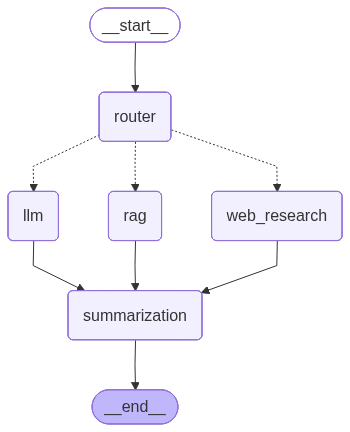

In [13]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid source
    print(app.get_graph().draw_mermaid())

## 10. Query Runner Utility

In [14]:
def run_query(query: str, thread_id: str = 'default') -> dict:
    """
    Execute a query through the multi-agent pipeline.
    thread_id enables persistent multi-turn conversation via MemorySaver.
    """
    print('=' * 70)
    print(f'USER QUERY: {query}')
    print('=' * 70)

    initial: AgentState = {
        'query':             query,
        'route':             '',
        'retrieved_context': '',
        'llm_response':      '',
        'final_summary':     '',
        'messages':          [],
        'metadata':          {},
    }
    result = app.invoke(initial, config={'configurable': {'thread_id': thread_id}})

    print('\n' + '=' * 70)
    print('FINAL RESPONSE')
    print('=' * 70)
    print(result['final_summary'])
    print('-' * 70)
    print(f"Route: {result['route'].upper()}  |  "
          f"Timestamp: {result['metadata'].get('timestamp', 'N/A')}")
    print('=' * 70)
    return result

print('run_query() ready.')

run_query() ready.


## 11. Test Queries

### Test 1 — RAG route (AI/ML knowledge base)

In [15]:
result1 = run_query(
    'What is RAG (Retrieval-Augmented Generation) and how does it work?',
    thread_id='t1'
)

USER QUERY: What is RAG (Retrieval-Augmented Generation) and how does it work?

[ROUTER] Analyzing: 'What is RAG (Retrieval-Augmented Generation) and how does it work?'
   Route: RAG | Reason: Query mentions RAG, a specific AI/LLM-related concept

[RAG] Retrieving for: 'What is RAG (Retrieval-Augmented Generation) and how does it work?'
   Retrieved 3 documents.

[SUMMARIZER] Synthesizing (via rag)...
   Generated 2379 chars.

FINAL RESPONSE
## Introduction to Retrieval-Augmented Generation (RAG)
Retrieval-Augmented Generation (RAG) is a technique used to enhance the performance of Large Language Models (LLMs) by combining retrieval-based and generative AI methods. This approach aims to reduce hallucinations and provide more factual and grounded answers by leveraging an external knowledge base.

## How RAG Works
The RAG process involves the following steps:
1. **Retrieval**: Relevant documents are retrieved from an external knowledge base based on the input prompt or query.
2. **Genera

### Test 2 — Web Research route (live information)

In [16]:
result2 = run_query(
    'What are the latest AI model releases in 2025?',
    thread_id='t2'
)

USER QUERY: What are the latest AI model releases in 2025?

[ROUTER] Analyzing: 'What are the latest AI model releases in 2025?'
   Route: WEB_RESEARCH | Reason: contains 'latest' and a specific year (2025)

[WEB RESEARCH] Searching: 'What are the latest AI model releases in 2025?'
   Found 5 results.

[SUMMARIZER] Synthesizing (via web_research)...
   Generated 3536 chars.

FINAL RESPONSE
## Introduction to 2025 AI Model Releases
The year 2025 has been significant for the development and release of various AI models, marking a transition towards more integrated, production-ready, and advanced AI technologies. This response aims to summarize the key AI model releases and developments in 2025, based on information from multiple sources.

### Notable AI Model Releases in 2025
Several notable AI models were released in 2025, including:
* **GPT-5 and GPT-5.1**: OpenAI's general-purpose models, with GPT-5 focusing on multimodal inputs and GPT-5.1 emphasizing stability, efficiency, and devel

### Test 3 — LLM direct route (general reasoning)

In [17]:
result3 = run_query(
    'Explain the difference between supervised and unsupervised learning.',
    thread_id='t3'
)

USER QUERY: Explain the difference between supervised and unsupervised learning.

[ROUTER] Analyzing: 'Explain the difference between supervised and unsupervised learning.'
   Route: LLM | Reason: general knowledge about machine learning concepts

[LLM AGENT] Answering: 'Explain the difference between supervised and unsupervised learning.'
   Generated 3284 chars.

[SUMMARIZER] Synthesizing (via llm)...
   Generated 3754 chars.

FINAL RESPONSE
## Introduction to Supervised and Unsupervised Learning
Machine learning is a field of study that gives computers the ability to learn without being explicitly programmed. Two fundamental types of machine learning approaches are supervised and unsupervised learning. The primary difference between them lies in the way the model learns from the data and the type of data used for training.

### Supervised Learning
Supervised learning is a type of machine learning where the model is trained on labeled data. Each example in the dataset is accompanied 

### Test 4 — RAG route (LangGraph / multi-agent)

In [18]:
result4 = run_query(
    'How does LangGraph help in building multi-agent systems?',
    thread_id='t4'
)

USER QUERY: How does LangGraph help in building multi-agent systems?

[ROUTER] Analyzing: 'How does LangGraph help in building multi-agent systems?'
   Route: RAG | Reason: Query mentions LangGraph and multi-agent systems, which are related to AI and ML topics

[RAG] Retrieving for: 'How does LangGraph help in building multi-agent systems?'
   Retrieved 3 documents.

[SUMMARIZER] Synthesizing (via rag)...
   Generated 2733 chars.

FINAL RESPONSE
## Introduction to LangGraph and Multi-Agent Systems
LangGraph is a framework designed to facilitate the creation of stateful, multi-actor applications that utilize Large Language Models (LLMs). It is built on top of LangChain, enabling the coordination of multiple chains or agents across computation steps in a cyclic manner. This capability is crucial for developing robust, production-ready agent architectures that can handle complex tasks.

## Role of LangGraph in Multi-Agent Systems
In the context of multi-agent systems, LangGraph plays a si

### Test 5 — Web Research route (current events)

In [19]:
result5 = run_query(
    'What is the current state of AI regulation in the European Union?',
    thread_id='t5'
)

USER QUERY: What is the current state of AI regulation in the European Union?

[ROUTER] Analyzing: 'What is the current state of AI regulation in the European Union?'
   Route: WEB_RESEARCH | Reason: current state implies recent information

[WEB RESEARCH] Searching: 'What is the current state of AI regulation in the European Union?'
   Found 5 results.

[SUMMARIZER] Synthesizing (via web_research)...
   Generated 3577 chars.

FINAL RESPONSE
## Introduction to AI Regulation in the European Union
The European Union (EU) has been at the forefront of regulating artificial intelligence (AI), with the aim of ensuring that fundamental rights, democracy, and environmental sustainability are protected from high-risk AI systems. The EU's regulatory framework for AI is evolving, with the EU AI Act being a key piece of legislation.

## The EU AI Act
The EU AI Act, which officially became law on August 1, 2024, is a comprehensive framework designed to govern the development, deployment, and use of

### Test 6 — Multi-turn conversation memory (same thread_id)

In [20]:
# Turn 1
result6a = run_query('What is prompt engineering?', thread_id='conv1')
# Turn 2 — follow-up, memory from Turn 1 is preserved
result6b = run_query('What are the most effective techniques you mentioned?', thread_id='conv1')

USER QUERY: What is prompt engineering?

[ROUTER] Analyzing: 'What is prompt engineering?'
   Route: RAG | Reason: prompt engineering is related to AI and LLMs

[RAG] Retrieving for: 'What is prompt engineering?'
   Retrieved 3 documents.

[SUMMARIZER] Synthesizing (via rag)...
   Generated 2677 chars.

FINAL RESPONSE
## Introduction to Prompt Engineering
Prompt engineering is a crucial aspect of working with Large Language Models (LLMs), as it involves designing effective input prompts to guide these models toward desired outputs. This technique has gained significant attention in recent years due to its potential to improve the accuracy of LLMs without requiring fine-tuning.

### Key Techniques in Prompt Engineering
Several key techniques are used in prompt engineering, including:
* **Zero-shot prompting**: This involves providing a prompt without any examples, and the model generates a response based on its understanding of the task.
* **Few-shot prompting**: This technique provides

## 12. Routing Summary

In [21]:
rows = [
    (result1['query'], result1['route']),
    (result2['query'], result2['route']),
    (result3['query'], result3['route']),
    (result4['query'], result4['route']),
    (result5['query'], result5['route']),
]
print('ROUTING SUMMARY')
print('-' * 70)
print(f"{'Query':<55} {'Route'}")
print('-' * 70)
for q, r in rows:
    trunc = q[:52] + '...' if len(q) > 52 else q
    print(f'{trunc:<55} {r.upper()}')
print('-' * 70)

ROUTING SUMMARY
----------------------------------------------------------------------
Query                                                   Route
----------------------------------------------------------------------
What is RAG (Retrieval-Augmented Generation) and how... RAG
What are the latest AI model releases in 2025?          WEB_RESEARCH
Explain the difference between supervised and unsupe... LLM
How does LangGraph help in building multi-agent syst... RAG
What is the current state of AI regulation in the Eu... WEB_RESEARCH
----------------------------------------------------------------------


## 13. System Report

### Agent Table

| Agent | Model / Tool | Role |
|---|---|---|
| **Router Agent** | Groq `llama-3.3-70b-versatile` (JSON output) | Routes query to `llm`, `rag`, or `web_research` |
| **Web Research Agent** | Tavily Search API | Fetches top-5 live web results |
| **RAG Agent** | ChromaDB + HuggingFace `all-MiniLM-L6-v2` | Top-3 semantic document retrieval |
| **LLM Agent** | Groq `llama-3.3-70b-versatile` | Answers general queries from parametric knowledge |
| **Summarization Agent** | Groq `llama-3.3-70b-versatile` | Synthesizes context into structured markdown response |

---

### Workflow and Decision-Making

1. Query enters `__start__` → **Router Agent** calls Groq and returns `{route, reason}` as JSON.
2. A **conditional edge** reads `state['route']` and dispatches to the correct specialist node.
3. Specialist populates `state['retrieved_context']`.
4. All paths converge at **Summarization Agent** → final markdown answer in `state['final_summary']`.
5. Graph reaches `END`.

---

### Routing Rules

| Route | Trigger |
|---|---|
| `web_research` | Keywords: *latest, current, today, now, recent, 2024, 2025, live, news* |
| `rag` | Topics: *LangGraph, Groq, RAG, transformer, LLM, fine-tuning, RLHF, vector DB, prompt engineering* |
| `llm` | Everything else: math, general reasoning, coding, creative writing |

---

### Memory (Conversational AI)

`MemorySaver` persists `state['messages']` across turns within a `thread_id`, enabling coherent multi-turn conversations where follow-up questions are answered in context.

---

### Graph Structure (Mermaid)

```mermaid
graph TD
    __start__ --> router
    router -->|web_research| web_research
    router -->|rag| rag
    router -->|llm| llm
    web_research --> summarization
    rag --> summarization
    llm --> summarization
    summarization --> __end__
```

---

### Expected Test Routing

| # | Query | Expected Route |
|---|---|---|
| 1 | What is RAG and how does it work? | **RAG** |
| 2 | Latest AI model releases in 2025? | **WEB_RESEARCH** |
| 3 | Supervised vs unsupervised learning | **LLM** |
| 4 | LangGraph and multi-agent systems? | **RAG** |
| 5 | Current EU AI regulation? | **WEB_RESEARCH** |
| 6a | What is prompt engineering? | **RAG** |
| 6b | Most effective techniques mentioned? | **RAG** (memory-aware) |